## Importing the necessary Libraries

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

In [49]:
# Load the Heart Diseaset
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [50]:
# Separate the predictor variables (𝑋) from the target variable (𝑦).
X = df.iloc[:,:-1]
y = df.iloc[:, -1]

Split the dataset into 80% training and 20% testing using train_test_split() with 
random_state=42 and stratify=y. 

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size = 0.8,
                                                    shuffle = True,
                                                    random_state = 42,
                                                    stratify = y)

 Create a Pipeline consisting of:  
o StandardScaler()  
o KNeighborsClassifier()  

In [52]:
# import the pipeline from sklearn
from sklearn.pipeline import Pipeline

In [53]:
model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors = 3))
    ])
    

Train a KNN classifier using the default value 𝑘 = 3 (n_neighbors=3) and evaluate its 
performance on the test dataset. 

In [54]:
# Importing the required Libraries for the evaluation of the model
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [55]:
# Fit the model for training
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['age','sex','cp',...,'slope','ca','thal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [56]:
# Predict the test data
y_pred = model.predict(X_test)

In [57]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")
print(cm)

Confusion Matrix
[[ 93   7]
 [  4 101]]


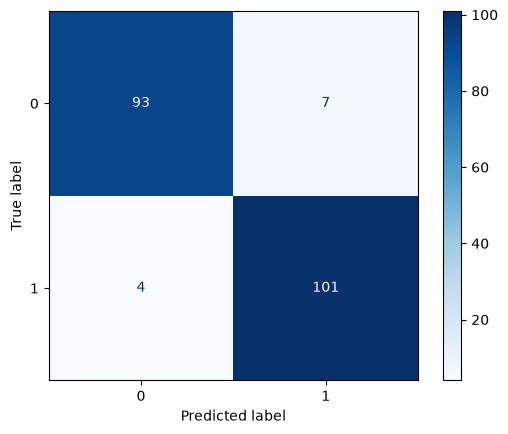

In [58]:
# Display the confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm
)

disp.plot(cmap = "Blues")
plt.show()

In [59]:
# Accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Precision
precision = precision_score(y_test, y_pred)
print(f"\nPrecison: {precision:.4f}")

# Recall
recall = recall_score(y_test, y_pred)
print(f"\nRecall: {recall:.4f}")

# F1-Score
f1 = f1_score(y_test, y_pred)
print(f"\nF1-Score: {f1:.4f}")

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.9463

Precison: 0.9352

Recall: 0.9619

F1-Score: 0.9484

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.93      0.94       100
           1       0.94      0.96      0.95       105

    accuracy                           0.95       205
   macro avg       0.95      0.95      0.95       205
weighted avg       0.95      0.95      0.95       205



Using 5-fold Cross-Validation (CV) on the training set only, determine the optimal 
value of 𝑘 by testing values of   
 
$k =1,2,3,…,20.$

In [60]:
# Candidate Values of K
k_values = range(1, 21)

cv_scores = []

# Evaluate each value of k
for k in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors = k))
    ])
    
    scores = cross_val_score(
        model,
        X, 
        y,
        cv = 5,
        scoring = "accuracy"
    )
    
    cv_scores.append(scores.mean())

In [61]:
# Best K
best_k = k_values[np.argmax(cv_scores)]

print(f"Best k: {best_k} ")
print(f"Best CV Accuracy: {max(cv_scores):.4f}")

Best k: 1 
Best CV Accuracy: 0.9815


Plot the Cross-Validation Accuracy against the corresponding values of 𝑘, and 
identify the value of 𝑘 that produces the highest average validation accuracy.

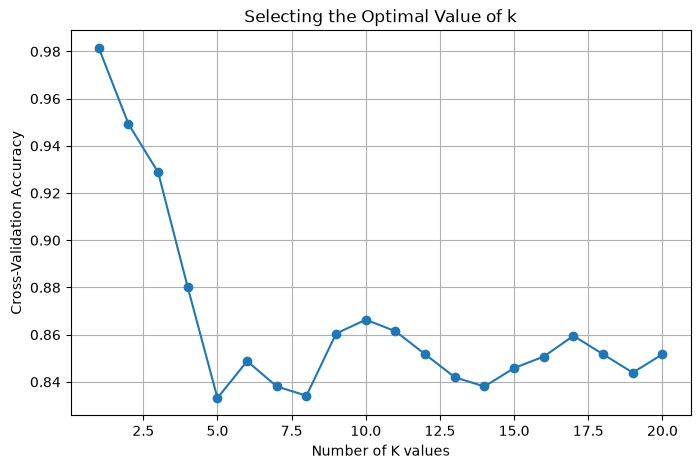

In [62]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, cv_scores, marker = 'o')
plt.xlabel("Number of K values")
plt.ylabel("Cross-Validation Accuracy")
plt.title("Selecting the Optimal Value of k")
plt.grid(True)
plt.show()

Retrain the KNN classifier using the optimal value of 𝑘obtained from Step 6. 

In [63]:
model_retrain = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors = 1))
])

In [64]:
# fit the model for training
model_retrain.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['age','sex','cp',...,'slope','ca','thal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [65]:
# Predicting with the model
y_retrain_pred = model_retrain.predict(X_test)

Evaluate the optimized model using the test dataset.

In [66]:
cm_new = confusion_matrix(y_test, y_retrain_pred)

print("The Confusion Matrix for the optimised Model")
print(cm_new)

The Confusion Matrix for the optimised Model
[[100   0]
 [  0 105]]


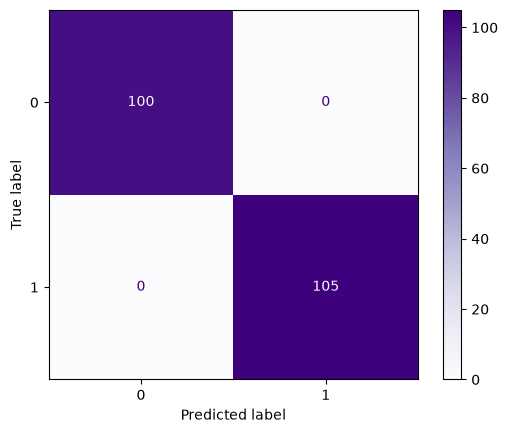

In [67]:
disp_new = ConfusionMatrixDisplay(
    confusion_matrix= cm_new
)

disp_new.plot(cmap = "Purples")
plt.show()

In [68]:
# Accuracy of the new Model
new_accuracy = accuracy_score(y_test, y_retrain_pred)
print(f"Accuracy: {new_accuracy}")

# Precision of the New Model
new_precision = precision_score(y_test, y_retrain_pred)
print(f"\nPrecision: {new_precision}")

# Recall of the New Model
new_recall = recall_score(y_test, y_retrain_pred)
print(f"\nRecall: {new_recall}")

# F1-score of the New Model
new_f1 = f1_score(y_test, y_retrain_pred)
print(f"\nF1: {new_f1}")

# Classification Report of the New Model
print(f"\nClassification: ")
print(classification_report(y_test, y_retrain_pred))

Accuracy: 1.0

Precision: 1.0

Recall: 1.0

F1: 1.0

Classification: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



 Compare the performance of

In [69]:
model_retrain.score(X_test, y_test)

1.0

In [70]:
comp_data = {
    "K Value = 3" : y_pred,
    "Optimal K Value = 1 " : y_retrain_pred
}

df_comp_data = pd.DataFrame(comp_data)
df_comp_data 

,K Value = 3,Optimal K Value = 1
0,0,0
1,0,1
2,0,0
3,1,1
4,0,0
...,...,...
200,0,0
201,0,0
202,0,0
203,1,1


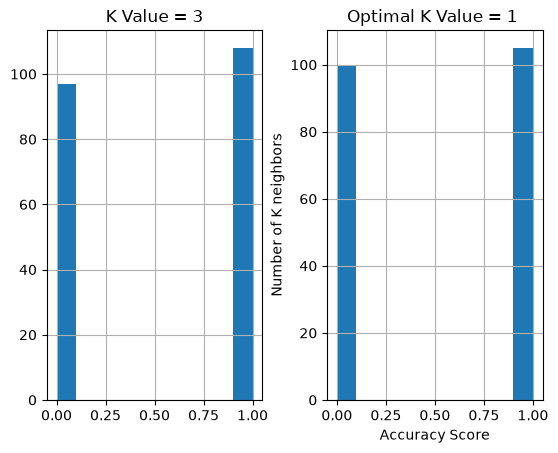

In [71]:
df_comp_data.hist()
plt.xlabel("Accuracy Score")
plt.ylabel("Number of K neighbors")
plt.show()

From the performance of the model when the default KNN model had _k_ set to `3` it can be seen that the accuracy score is `0.8439` which is low compared to the performance when the model used a Cross Validation to optimize the value of _k_. given the optimal _k_ value to be `1`, we got an accuracy score of `1.0`. meaning that our model performs better when we do not use use a random value for _k_. 